## Viscoplastic model with hysteresis (Bauschinger effect)


# 1. Kinematics (unchanged)

$$
\boxed{
\varepsilon = \varepsilon^e + \varepsilon^{vp}
}
$$

# 2. State variables

We extend the state:

$$
\boxed{
\mathbf{y} =
\begin{bmatrix}
\sigma \\
\varepsilon^{vp} \\
X
\end{bmatrix}
}
$$

where:

* $\sigma$ = stress
* $\varepsilon^{vp}$ = plastic strain
* $X$ = **backstress** (kinematic hardening)

# 3. Elastic law

$$
\boxed{
\sigma = E(\varepsilon - \varepsilon^{vp})
}
$$

# 4. Yield function with kinematic hardening

$$
\boxed{
f(\sigma, X)
=
|\sigma - X| - \sigma_y
}
$$

* $\sigma - X$ = effective stress
* this shifts the yield surface → produces hysteresis

# 5. Viscoplastic flow rule

$$
\boxed{
\dot{\varepsilon}^{vp}
=
\gamma
\left\langle
\frac{|\sigma - X| - \sigma_y}{\sigma_0}
\right\rangle^n
\operatorname{sign}(\sigma - X)
}
$$

Define:

$$
\lambda := f_{vis}( \sigma - X )
$$

# 6. Kinematic hardening (Armstrong–Frederick)

$$
\boxed{
\dot{X}
=
C\,\dot{\varepsilon}^{vp}
-
\gamma_X\,X\,|\dot{\varepsilon}^{vp}|
}
$$


### Terms:

* $C$: hardening modulus
* $\gamma_X$: dynamic recovery

✅ First term → builds backstress  
✅ Second term → limits growth (saturation)

# 7. Evolution equations

## Plastic strain

$$
\boxed{
\dot{h} = \lambda
}
\quad (h = \varepsilon^{vp})
$$

## Backstress

$$
\boxed{
\dot{X} =
C \lambda - \gamma_X X |\lambda|
}
$$

## Stress evolution

$$
\sigma = E(\varepsilon - h)
$$

$$
\boxed{
\dot{\sigma} = E \dot{\varepsilon} - E \lambda
}
$$



# 8. Final dynamical system

$$
\boxed{
\begin{aligned}
\dot{\sigma} &= E \dot{\varepsilon} - E \lambda \\
\dot{h} &= \lambda \\
\dot{X} &= C \lambda - \gamma_X X |\lambda|
\end{aligned}
}
$$


#  9. Controlled Differential Equation (CDE form)


Define:

$$
\mathbf{u} =
\begin{bmatrix}
\dot{\varepsilon} \\
1
\end{bmatrix}
$$


Then:

$$
\boxed{
\dot{\mathbf{y}} =
\mathbf{J}(\mathbf{y})
\mathbf{u}
}
$$


## Jacobian operator

$$
\boxed{
\mathbf{J}(\mathbf{y}) =
\begin{bmatrix}
E & -E\lambda \\
0 & \lambda \\
0 & C\lambda - \gamma_X X |\lambda|
\end{bmatrix}
}
$$


### Dimensions:

* $$\mathbf{y} \in \mathbb{R}^3$$
* $$\mathbf{J} \in \mathbb{R}^{3 \times 2}$$


# 10. Full explicit CDE form

$$
\boxed{
\begin{bmatrix}
\dot{\sigma} \\
\dot{h} \\
\dot{X}
\end{bmatrix}
=
\begin{bmatrix}
E & -E\lambda \\
0 & \lambda \\
0 & C\lambda - \gamma_X X |\lambda|
\end{bmatrix}
\begin{bmatrix}
\dot{\varepsilon} \\
1
\end{bmatrix}
}
$$

***

# 11. Key physical behavior


## ✅ Hysteresis (cyclic loading)

* backstress $X$ shifts yield surface
* produces **Bauschinger effect**
* asymmetric loading–unloading


## ✅ Stress relaxation

If:

$$
\dot{\varepsilon} = 0
$$

$$
\dot{\sigma} = -E\lambda
$$

✅ stress decays


## Creep

$$
\dot{h} = \lambda
$$

plastic strain keeps evolving

# 12. Key insight

> Adding $X$ makes the system **memory-dependent with directional history**


Compared to your original model:

| Model         | Behavior                         |
| ------------- | -------------------------------- |
| without $X$ | symmetric loops                  |
| with $X$    | shifted loops / cyclic hardening |

***

# 13. ML framework

This structure is PERFECT for:

✅ Neural CDE  
✅ Neural operator  
✅ learning hysteresis  
✅ learning path dependence


## Neural version becomes:

$$
\dot{\mathbf{y}} =
\mathcal{N}_\theta(\mathbf{y}, \dot{\varepsilon})
$$

where NN learns:

* $\lambda(\sigma, X)$
* evolution of $X$

***

# 14. Final compact form

$$
\boxed{
\dot{\mathbf{y}} =
\begin{bmatrix}
E\dot{\varepsilon} \\
0 \\
0
\end{bmatrix}
+
\lambda(\sigma,X)
\begin{bmatrix}
- E \\
1 \\
C - \gamma_X X \operatorname{sign}(\lambda)
\end{bmatrix}
}
$$



## ✅ Complete 1D viscoplastic + kinematic hardening model:

$$
\boxed{
\begin{aligned}
\sigma &= E(\varepsilon - \varepsilon^{vp}) \\
\dot{\varepsilon}^{vp} &= f(\sigma - X) \\
\dot{X} &= C \dot{\varepsilon}^{vp} - \gamma_X X |\dot{\varepsilon}^{vp}| \\
\dot{\sigma} &= E\dot{\varepsilon} - E \dot{\varepsilon}^{vp}
\end{aligned}
}
$$


✅ Captures:

* hysteresis
* Bauschinger effect
* creep
* relaxation
* rate dependence



In [ ]:
import jax
import jax.numpy as jnp
import diffrax
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
jax.config.update("jax_enable_x64", True)

from ipywidgets import interact
%matplotlib qt
import pyqtgraph as pg
from pyqtgraph.Qt import QtGui
plt.rcdefaults()

# figure styling
font = 16
font_axis = 20
plt.rcParams.update({'font.size': font})    # Set the desired font size
plt.rcParams['figure.facecolor'] = 'white'  # Background color for figures
plt.rcParams['axes.facecolor'] = 'white'    # Background color for axes

In [ ]:
# ---------------------------------------------------------------------------
# Prescribed total-strain history  ε(t)  and its time-derivative  ε̇(t)
# ---------------------------------------------------------------------------
def total_strain(t):
    """Triangular ramp: load → hold → unload → hold → reload …"""
    strain_rate = 1e-3      # [1/s]
    period      = 2.0       # [s]  full cycle
    phase       = (t % period) / period          # in [0,1)
    # linear ramp up then down
    ramp = jnp.where(phase < 0.5,
                     4.0 * phase - 1.0,          # -1 → +1
                     3.0 - 4.0 * phase)          # +1 → -1
    return strain_rate * ramp                     # dimensionless strain


def strain_rate(t):
    """Analytical derivative of total_strain(t)."""
    sr   = 1e-3
    period = 2.0
    phase  = (t % period) / period
    # derivative of ramp (piecewise constant)
    return jnp.where(phase < 0.5,
                     sr * 4.0 / period,
                    -sr * 4.0 / period)

def strain_cyclic(t):
    return 0.01 * jnp.sin(2*jnp.pi*0.1 * t)

def strain_rate_cyclic(t):
    return 0.01 * 2*jnp.pi*0.1 * jnp.cos(2*jnp.pi*0.1 * t)

# 2. STRESS RELAXATION
def strain_relax(t):
    return jnp.where(t < 5.0, 0.002 * t, 0.01)

def strain_rate_relax(t):
    return jnp.where(t < 5.0, 0.002, 0.0)

# 3. CREEP-LIKE RESPONSE
def strain_creep(t):
    return jnp.where(t < 1.0, 0.01 * t, 0.01)

def strain_rate_creep(t):
    return jnp.where(t < 1.0, 0.01, 0.0)

# ---------------------------------------------------------------------------
# Prescribed total-strain history  ε(t)  and its time-derivative  ε̇(t)
# ---------------------------------------------------------------------------
def total_strain(t):
    """Sinusoidal cyclic loading: ε(t) = 0.01 · sin(2π · 0.1 · t)"""
    return 0.01 * jnp.sin(2 * jnp.pi * 1 * t)


def strain_rate(t):
    """Analytical derivative: ε̇(t) = 0.01 · 2π · 0.1 · cos(2π · 0.1 · t)"""
    return 0.01 * 2 * jnp.pi * 1 * jnp.cos(2 * jnp.pi * 1 * t)

    
# ---------------------------------------------------------------------------
# Prescribed total-strain history  ε(t)  and its time-derivative  ε̇(t)
#
# Trapezoidal waveform — dwell at POSITIVE peak only:
#
#   +A ─────┐
#            ╲
#   -A        └──────────  (no hold; ramps immediately back up)
#
#   |<t_ramp>|<─t_hold─>|<t_ramp>|   one period
#
# ---------------------------------------------------------------------------
AMPLITUDE = 0.01   # strain amplitude             [−]
T_RAMP    = 2.0    # ramp duration (one leg)      [s]
T_HOLD    = 3.0    # dwell duration at +A only    [s]
# derived
PERIOD    = 2.0 * T_RAMP + T_HOLD   # = 7 s per cycle
 
 
def total_strain(t):
    """Trapezoidal strain with hold at positive peak only."""
    A, tr, th = AMPLITUDE, T_RAMP, T_HOLD
    phase = t % PERIOD
    return jnp.where(
        phase < tr,
            A * (2.0 * phase / tr - 1.0),                      # ramp  −A → +A
        jnp.where(
            phase < tr + th,
                A,                                             # dwell  +A
                A * (1.0 - 2.0 * (phase - tr - th) / tr)       # ramp  +A → −A
        )
    )
 
 
def strain_rate(t):
    """Piecewise-constant derivative of total_strain(t)."""
    A, tr, th = AMPLITUDE, T_RAMP, T_HOLD
    phase = t % PERIOD
    return jnp.where(
        phase < tr,
            2.0 * A / tr,           # positive ramp
        jnp.where(
            phase < tr + th,
                0.0,                # dwell at +A
                -2.0 * A / tr       # negative ramp
        )
    )    

In [52]:
"""
Viscoplastic ODE Solver using Diffrax
======================================
Dynamical system (Images 1-3):

    ẏ = [ E·ε̇ − E·f(σ) ]    y = [σ, h]
        [      f(σ)      ]    h := ε^vp

Flow rule (Perzyna-type):
    f(σ) = γ · ⟨(|σ| − σ_y) / σ₀⟩ⁿ · sign(σ)

where ⟨·⟩ = max(0, ·) is the Macaulay bracket.
"""
# ---------------------------------------------------------------------------
# Material parameters
# ---------------------------------------------------------------------------
params = dict(
    E=210e3,   # Young's modulus [MPa]
    gamma=1e-4,    # viscosity coefficient [1/s]
    sigma_y=250.0, # yield stress [MPa]
    sigma_0=200.0, # normalisation stress [MPa]
    n=10.0,         # rate-sensitivity exponent [-]
)

# ---------------------------------------------------------------------------
# Flow rule  f(σ) = γ ⟨(|σ| − σ_y)/σ₀⟩ⁿ sign(σ)
# ---------------------------------------------------------------------------
def flow_rule(sigma, p):
    overstress = (jnp.abs(sigma) - p["sigma_y"]) / p["sigma_0"]
    macaulay   = jnp.maximum(0.0, overstress)          # ⟨·⟩
    return p["gamma"] * macaulay ** p["n"] * jnp.sign(sigma)

# ---------------------------------------------------------------------------
# RHS of the ODE
#   ẏ[0] = E · ε̇(t) − E · f(σ)
#   ẏ[1] = f(σ)
# ---------------------------------------------------------------------------
def rhs(t, y, args):
    p          = args
    sigma, _h  = y[0], y[1]
    f_sigma    = flow_rule(sigma, p)
    eps_dot    = strain_rate(t)
    sigma_dot  = p["E"] * eps_dot - p["E"] * f_sigma
    h_dot      = f_sigma
    return jnp.array([sigma_dot, h_dot])


# ---------------------------------------------------------------------------
# Solve with Diffrax
# ---------------------------------------------------------------------------
def solve(t0=0.0, t1=6.0, dt0=1e-2, y0=None, p=None):
    if p   is None: p  = params
    if y0  is None: y0 = jnp.zeros(2)      # [σ₀, h₀] = [0, 0]

    term    = diffrax.ODETerm(rhs)
    solver  = diffrax.Tsit5()               # explicit RK4(5); good for stiff-ish problems
    # Use adaptive step-size control
    # stepsize_controller = diffrax.PIDController(rtol=1e-6, atol=1e-8)

    saveat  = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 1000))

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=p,
        saveat=saveat,
        # stepsize_controller=stepsize_controller,
        max_steps=50000,
    )
    return sol


# ---------------------------------------------------------------------------
# Post-process
# ---------------------------------------------------------------------------
def postprocess(sol):
    ts     = sol.ts
    sigma  = sol.ys[:, 0]
    h      = sol.ys[:, 1]                  # ε^vp
    eps_total = jax.vmap(total_strain)(ts)
    eps_el    = sigma / params["E"]        # elastic strain
    return ts, sigma, h, eps_total, eps_el


# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
def plot(ts, sigma, h, eps_total, eps_el):
    fig = plt.figure(figsize=(14, 9), facecolor="#0f0f14")
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    accent = "#e8c87a"
    red    = "#e87a7a"
    blue   = "#7ab4e8"
    green  = "#7ae8b4"
    bg     = "#0f0f14"
    panel  = "#1a1a24"
    grid_c = "#2a2a3a"
    txt    = "#d8d8e8"

    def styled_ax(ax, title):
        ax.set_facecolor(panel)
        for spine in ax.spines.values():
            spine.set_color(grid_c)
        ax.tick_params(colors=txt, labelsize=9)
        ax.xaxis.label.set_color(txt)
        ax.yaxis.label.set_color(txt)
        ax.set_title(title, color=accent, fontsize=11, pad=8)
        ax.grid(color=grid_c, linewidth=0.5, linestyle="--")
        return ax

    # 1. Stress vs time
    ax1 = styled_ax(fig.add_subplot(gs[0, 0]), "Stress σ(t)")
    ax1.plot(ts, sigma, '.-', color=accent, lw=1.5)
    ax1.axhline( params["sigma_y"], color=red,  lw=0.8, ls=":", label="+σ_y")
    ax1.axhline(-params["sigma_y"], color=red,  lw=0.8, ls=":", label="−σ_y")
    ax1.set_xlabel("time [s]")
    ax1.set_ylabel("σ [MPa]")
    ax1.legend(fontsize=8, labelcolor=txt, framealpha=0)

    # 2. Viscoplastic strain h vs time
    ax2 = styled_ax(fig.add_subplot(gs[0, 1]), "Viscoplastic strain  h = ε^vp(t)")
    ax2.plot(ts, h, color=green, lw=1.5)
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("ε^vp  [−]")

    # 3. Stress–strain (hysteresis loop)
    ax3 = styled_ax(fig.add_subplot(gs[1, 0]), "Stress–strain hysteresis")
    ax3.plot(eps_total * 1e3, sigma, '.-', color=blue, lw=1.2)
    ax3.set_xlabel("ε_total  [‰]")
    ax3.set_ylabel("σ [MPa]")

    # 4. Strain decomposition vs time
    ax4 = styled_ax(fig.add_subplot(gs[1, 1]), "Strain decomposition")
    ax4.plot(ts, eps_total * 1e3, color=accent, lw=1.2, label="ε_total")
    ax4.plot(ts, eps_el   * 1e3, color=blue,   lw=1.2, label="ε_el")
    ax4.plot(ts, h        * 1e3, color=green,  lw=1.2, label="ε^vp")
    ax4.set_xlabel("time [s]")
    ax4.set_ylabel("[‰]")
    ax4.legend(fontsize=8, labelcolor=txt, framealpha=0)

    fig.suptitle(
        "Viscoplastic ODE  ·  Diffrax / Tsit5",
        color=txt, fontsize=13, y=0.98
    )

    # plt.savefig("/mnt/user-data/outputs/viscoplastic_result.png",
    #             dpi=160, bbox_inches="tight", facecolor=bg)
    # plt.close()
    # print("Plot saved.")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    print("Solving viscoplastic ODE …")
    sol = solve(t0=0.0, t1=7.0, dt0=1e-2)
    ts, sigma, h, eps_total, eps_el = postprocess(sol)
    print(f"  Steps taken : {sol.stats['num_steps']}")
    print(f"  σ_max       : {sigma.max():.2f} MPa")
    print(f"  ε^vp_final  : {h[-1]:.6f}")
    plot(ts, sigma, h, eps_total, eps_el)
    print("Done.")

Solving viscoplastic ODE …
  Steps taken : 700
  σ_max       : 566.98 MPa
  ε^vp_final  : 0.002477
Done.


In [56]:
"""
Viscoplastic ODE Solver with Kinematic Hardening — Diffrax
============================================================
State vector:  y = [σ, h, α]
    σ  — stress                 [MPa]
    h  — viscoplastic strain    ε^vp  [−]
    α  — back-stress            [MPa]

Dynamical system:
    σ̇ = E·ε̇ − E·f(σ, α)
    ḣ = f(σ, α)
    α̇ = C·f(σ, α) − D·α·|f(σ, α)|      ← Armstrong-Frederick

Flow rule (Perzyna-type, shifted by back-stress):
    f(σ, α) = γ · ⟨(|σ − α| − σ_y) / σ₀⟩ⁿ · sign(σ − α)

where ⟨·⟩ = max(0, ·) is the Macaulay bracket.
  C  — kinematic hardening modulus  [MPa]
  D  — dynamic recovery parameter   [−]    (D=0 → linear kinematic hardening)
"""

# ---------------------------------------------------------------------------
# Material parameters
# ---------------------------------------------------------------------------
params = dict(
    E=210e3,   # Young's modulus                         [MPa]
    gamma=1e-4,    # viscosity coefficient               [1/s]
    sigma_y=250.0, # initial yield stress                [MPa]
    sigma_0=200.0, # normalisation stress                [MPa]
    n=10.0,         # rate-sensitivity exponent           [−]
    C=10e3,    # kinematic hardening modulus             [MPa]
    D=40.0,        # Armstrong-Frederick recovery param   [−]  (D=0 → linear)
)

# ---------------------------------------------------------------------------
# Flow rule with kinematic hardening (back-stress α shifts yield surface):
#   f(σ,α) = γ ⟨(|σ−α| − σ_y)/σ₀⟩ⁿ sign(σ−α)
# ---------------------------------------------------------------------------
def flow_rule(sigma, alpha, p):
    eta        = sigma - alpha                           # shifted stress
    overstress = (jnp.abs(eta) - p["sigma_y"]) / p["sigma_0"]
    macaulay   = jnp.maximum(0.0, overstress)            # ⟨·⟩
    return p["gamma"] * macaulay ** p["n"] * jnp.sign(eta)

# ---------------------------------------------------------------------------
# RHS of the ODE
#   ẏ[0] = E · ε̇(t) − E · f(σ, α)
#   ẏ[1] = f(σ, α)
#   ẏ[2] = C · f(σ, α) − D · α · |f(σ, α)|    ← Armstrong-Frederick
# ---------------------------------------------------------------------------
def rhs(t, y, args):
    p                = args
    sigma, _h, alpha = y[0], y[1], y[2]
    f_sigma          = flow_rule(sigma, alpha, p)
    eps_dot          = strain_rate(t)
    sigma_dot        = p["E"] * eps_dot - p["E"] * f_sigma
    h_dot            = f_sigma
    alpha_dot        = p["C"] * f_sigma - p["D"] * alpha * jnp.abs(f_sigma)
    return jnp.array([sigma_dot, h_dot, alpha_dot])


# ---------------------------------------------------------------------------
# Solve with Diffrax
# ---------------------------------------------------------------------------
def solve(t0=0.0, t1=100.0, dt0=1e-2, y0=None, p=None):
    if p   is None: p  = params
    if y0  is None: y0 = jnp.zeros(3)      # [σ₀, h₀, α₀] = [0, 0, 0]

    term    = diffrax.ODETerm(rhs)
    solver  = diffrax.Tsit5()               # Tsit5 explicit RK4(5); good for stiff-ish problems
    # Use adaptive step-size control
    # stepsize_controller = diffrax.PIDController(rtol=1e-6, atol=1e-8)

    saveat  = diffrax.SaveAt(ts=jnp.linspace(t0, t1, 1000))

    sol = diffrax.diffeqsolve(
        term,
        solver,
        t0=t0,
        t1=t1,
        dt0=dt0,
        y0=y0,
        args=p,
        saveat=saveat,
        # stepsize_controller=stepsize_controller,
        max_steps=50000,
    )
    return sol


# ---------------------------------------------------------------------------
# Post-process
# ---------------------------------------------------------------------------
def postprocess(sol):
    ts        = sol.ts
    sigma     = sol.ys[:, 0]
    h         = sol.ys[:, 1]               # ε^vp
    alpha     = sol.ys[:, 2]               # back-stress
    eps_total = jax.vmap(total_strain)(ts)
    eps_el    = sigma / params["E"]
    return ts, sigma, h, alpha, eps_total, eps_el

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
def plot(ts, sigma, h, alpha, eps_total, eps_el):
    fig = plt.figure(figsize=(15, 10), facecolor="#0f0f14")
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)

    accent = "#e8c87a"
    purple = "#c87ae8"
    red    = "#e87a7a"
    blue   = "#7ab4e8"
    green  = "#7ae8b4"
    bg     = "#0f0f14"
    panel  = "#161515"
    grid_c = "#2a2a3a"
    txt    = "#d8d8e8"

    def styled_ax(ax, title):
        ax.set_facecolor(panel)
        for spine in ax.spines.values():
            spine.set_color(grid_c)
        ax.tick_params(colors=txt, labelsize=9)
        ax.xaxis.label.set_color(txt)
        ax.yaxis.label.set_color(txt)
        ax.set_title(title, color=accent, fontsize=11, pad=8)
        ax.grid(color=grid_c, linewidth=0.5, linestyle="--")
        return ax

    # 1. Stress vs time
    ax1 = styled_ax(fig.add_subplot(gs[0, 0]), "Stress σ(t)")
    ax1.plot(ts, sigma, color=accent, lw=1.5, label="σ")
    ax1.plot(ts, alpha, color=purple, lw=1.2, ls="--", label="α (back-stress)")
    ax1.axhline( params["sigma_y"], color=red, lw=0.7, ls=":", label="±σ_y")
    ax1.axhline(-params["sigma_y"], color=red, lw=0.7, ls=":")
    ax1.set_xlabel("time [s]")
    ax1.set_ylabel("[MPa]")
    ax1.legend(fontsize=8, labelcolor=txt, framealpha=0)

    # 2. Back-stress α vs time
    ax2 = styled_ax(fig.add_subplot(gs[0, 1]), "Back-stress α(t)")
    ax2.plot(ts, alpha, color=purple, lw=1.5)
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("α [MPa]")

    # 3. Viscoplastic strain h vs time
    ax3 = styled_ax(fig.add_subplot(gs[0, 2]), "Viscoplastic strain  ε^vp(t)")
    ax3.plot(ts, h * 1e3, color=green, lw=1.5)
    ax3.set_xlabel("time [s]")
    ax3.set_ylabel("ε^vp  [‰]")

    # 4. Stress–strain hysteresis (all cycles, coloured by time)
    ax4 = styled_ax(fig.add_subplot(gs[1, 0]), "Stress–strain hysteresis")
    n_pts = len(ts)
    colors = plt.cm.plasma(jnp.linspace(0.1, 0.9, n_pts))
    ax4.scatter(eps_total * 1e3, sigma, c=colors, s=0.3, linewidths=0)
    ax4.set_xlabel("ε_total  [‰]")
    ax4.set_ylabel("σ [MPa]")

    # 5. Stress vs back-stress (shows saturation of hardening)
    ax5 = styled_ax(fig.add_subplot(gs[1, 1]), "σ vs back-stress α")
    ax5.scatter(alpha, sigma, c=colors, s=0.3, linewidths=0)
    ax5.plot([-1, 1], [-1, 1], color=red, lw=0.6, ls=":",
             transform=ax5.transAxes, label="σ = α")
    ax5.set_xlabel("α [MPa]")
    ax5.set_ylabel("σ [MPa]")

    # 6. Strain decomposition vs time
    ax6 = styled_ax(fig.add_subplot(gs[1, 2]), "Strain decomposition")
    ax6.plot(ts, eps_total * 1e3, color=accent, lw=1.2, label="ε_total")
    ax6.plot(ts, eps_el   * 1e3, color=blue,   lw=1.2, label="ε_el")
    ax6.plot(ts, h        * 1e3, color=green,  lw=1.2, label="ε^vp")
    ax6.set_xlabel("time [s]")
    ax6.set_ylabel("[‰]")
    ax6.legend(fontsize=8, labelcolor=txt, framealpha=0)

    # Colourbar for cycle number
    sm = plt.cm.ScalarMappable(cmap="plasma",
                                norm=plt.Normalize(vmin=0, vmax=100))
    cb = fig.colorbar(sm, ax=[ax4, ax5], shrink=0.6, pad=0.02)
    cb.set_label("time [s]", color=txt, fontsize=9)
    cb.ax.yaxis.set_tick_params(color=txt, labelcolor=txt)

    fig.suptitle(
        "Viscoplastic model + Armstrong-Frederick kinematic hardening  ·  Diffrax / Tsit5",
        color=txt, fontsize=12, y=0.995
    )

    # plt.savefig("/mnt/user-data/outputs/viscoplastic_result.png",
    #             dpi=160, bbox_inches="tight", facecolor=bg)
    # plt.close()
    # print("Plot saved.")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    print("Solving viscoplastic ODE …")
    sol = solve(t0=0.0, t1=7.0, dt0=1e-3)   # 2 cycles at f = 1 Hz
    ts, sigma, h, alpha, eps_total, eps_el = postprocess(sol)
    print(f"  Steps taken : {sol.stats['num_steps']}")
    print(f"  σ_max       : {sigma.max():.2f} MPa")
    print(f"  α_final     : {alpha[-1]:.2f} MPa")
    print(f"  ε^vp_final  : {h[-1]:.6f}")
    plot(ts, sigma, h, alpha, eps_total, eps_el)
    print("Done.")

Solving viscoplastic ODE …
  Steps taken : 7000
  σ_max       : 688.00 MPa
  α_final     : -39.98 MPa
  ε^vp_final  : 0.002862
Done.


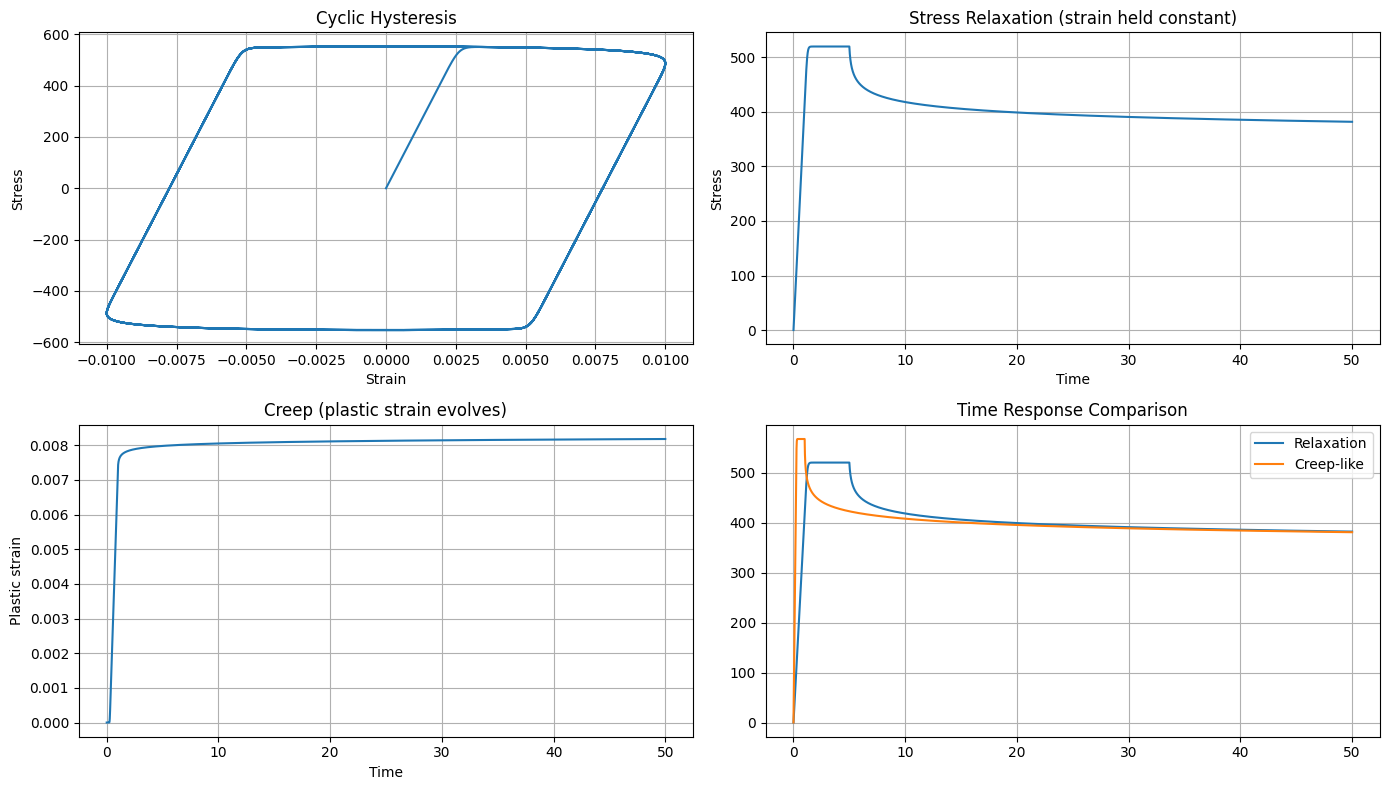

In [15]:
# Explicit solver for the simple viscoplastic model (no hardening)
# # =============================
# Material parameters
# =============================
E = 210e3       # MPa
sigma_y = 250.0
gamma = 0.0001
sigma_0 = 200.0
n = 10.0

# =============================
# Flow rule
# =============================
def flow_rule(sigma):
    f = abs(sigma) - sigma_y
    if f > 0:
        return gamma * (f / sigma_0)**n * np.sign(sigma)
    else:
        return 0.0

# =============================
# Time integration (explicit Euler)
# =============================
def solve_problem(strain, strain_rate, T=50.0, dt=0.001):

    time = np.arange(0, T, dt)
    n_steps = len(time)

    sigma = np.zeros(n_steps)
    h = np.zeros(n_steps)  # plastic strain

    for i in range(1, n_steps):

        deps = strain_rate(time[i])
        f = flow_rule(sigma[i-1])

        # CDE update
        dsigma = E * deps - E * f
        dh = f

        # explicit Euler
        sigma[i] = sigma[i-1] + dt * dsigma
        h[i] = h[i-1] + dt * dh

    eps = strain(time)

    return time, eps, sigma, h

# =============================
# 1. CYCLIC LOADING
# =============================
def strain_cyclic(t):
    return 0.01 * np.sin(2*np.pi*0.1 * t)

def strain_rate_cyclic(t):
    return 0.01 * 2*np.pi*0.1 * np.cos(2*np.pi*0.1 * t)

# =============================
# 2. STRESS RELAXATION
# =============================
def strain_relax(t):
    return np.where(t < 5.0, 0.002 * t, 0.01)

def strain_rate_relax(t):
    return np.where(t < 5.0, 0.002, 0.0)

# =============================
# 3. CREEP-LIKE RESPONSE
# =============================
def strain_creep(t):
    return np.where(t < 1.0, 0.01 * t, 0.01)

def strain_rate_creep(t):
    return np.where(t < 1.0, 0.01, 0.0)

# =============================
# RUN SIMULATIONS
# =============================
time_cyc, eps_cyc, sigma_cyc, h_cyc = solve_problem(
    strain_cyclic, strain_rate_cyclic
)

time_rel, eps_rel, sigma_rel, h_rel = solve_problem(
    strain_relax, strain_rate_relax
)

time_crp, eps_crp, sigma_crp, h_crp = solve_problem(
    strain_creep, strain_rate_creep
)

# =============================
# PLOTS
# =============================

plt.figure(figsize=(14,8))

# 1. Hysteresis
plt.subplot(2,2,1)
plt.plot(eps_cyc, sigma_cyc)
plt.title("Cyclic Hysteresis")
plt.xlabel("Strain")
plt.ylabel("Stress")
plt.grid()

# 2. Relaxation
plt.subplot(2,2,2)
plt.plot(time_rel, sigma_rel)
plt.title("Stress Relaxation (strain held constant)")
plt.xlabel("Time")
plt.ylabel("Stress")
plt.grid()

# 3. Creep-like
plt.subplot(2,2,3)
plt.plot(time_crp, h_crp)
plt.title("Creep (plastic strain evolves)")
plt.xlabel("Time")
plt.ylabel("Plastic strain")
plt.grid()

# 4. Combined comparison
plt.subplot(2,2,4)
plt.plot(time_rel, sigma_rel, label="Relaxation")
plt.plot(time_crp, sigma_crp, label="Creep-like")
plt.legend()
plt.title("Time Response Comparison")
plt.grid()

plt.tight_layout()
plt.show()